# Chess Game Outcome Prediction

## Project Overview

This notebook performs **exploratory data analysis (EDA)** and **machine learning classification** on a dataset of chess games. The goal is to predict the **winner** of a chess game (white or black) based on features such as player ratings, game type, time controls, and opening strategy.

### Workflow Summary
1. **Data Loading & Exploration** — Understand the structure, types, and distributions
2. **Data Cleaning & Feature Engineering** — Drop irrelevant columns, encode categoricals, create derived features
3. **Modeling (Logistic Regression)** — Train a baseline model with full and reduced feature sets
4. **Modeling (Random Forest)** — Train an ensemble model for comparison
5. **Model Evaluation & Comparison** — Cross-validation, confusion matrices, and feature importance analysis

---

## 1. Import Libraries

Import the essential Python libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`sklearn`).

**Impact:** Establishes the environment and toolset for the entire analysis pipeline.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split

## 2. Load the Dataset

Read the chess games CSV file into a pandas DataFrame and preview the first 5 rows using `head()`.

**Impact:** Provides an initial understanding of the dataset's columns, data types, and sample values.

In [2]:
df = pd.read_csv("games.csv")
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


### Preview Last Rows

Display the last 5 rows with `tail()` to check for anomalies or inconsistencies at the end of the dataset.

**Impact:** Helps detect data truncation issues, missing values, or unexpected patterns at the tail end.

In [3]:
df.tail()


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
20053,EfqH7VVH,True,1.499791e+12,1.499791e+12,24,resign,white,10+10,belcolt,1691,jamboger,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2
20054,WSJDhbPl,True,1.499698e+12,1.499699e+12,82,mate,black,10+0,jamboger,1233,farrukhasomiddinov,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,A41,Queen's Pawn,2
20055,yrAas0Kj,True,1.499698e+12,1.499698e+12,35,mate,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3
20056,b0v4tRyF,True,1.499696e+12,1.499697e+12,109,resign,white,10+0,marcodisogno,1360,jamboger,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,B07,Pirc Defense,4
20057,N8G2JHGG,True,1.499643e+12,1.499644e+12,78,mate,black,10+0,jamboger,1235,ffbob,1339,d4 d5 Bf4 Na6 e3 e6 c3 Nf6 Nf3 Bd7 Nbd2 b5 Bd3...,D00,Queen's Pawn Game: Mason Attack,3


### Dataset Information

Use `info()` to display the number of rows, columns, data types, and non-null counts.

**Impact:** Reveals the dataset dimensions, identifies columns with missing values, and confirms data types for each feature.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage: 2.3 MB


### Identify Categorical Columns

Select columns with `object` (string) data types to identify which features require encoding before modeling.

**Impact:** Identifies categorical features that will need to be converted to numerical representations for ML algorithms.

In [5]:
df.select_dtypes(include="object").columns

/tmp/ipykernel_3687/1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['id', 'victory_status', 'winner', 'increment_code', 'white_id',
       'black_id', 'moves', 'opening_eco', 'opening_name'],
      dtype='str')

### Statistical Summary

Generate descriptive statistics (mean, std, min, max, quartiles) for all numerical columns.

**Impact:** Provides a quick overview of feature distributions, helps identify outliers, and reveals the scale of different features.

In [6]:
df.describe()

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


---

## 3. Data Cleaning & Feature Engineering

### Review Before Cleaning

Preview the data before applying transformations to establish a reference point.

**Impact:** Serves as a checkpoint to compare the dataset before and after cleaning operations.

In [7]:
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


### Drop Irrelevant Columns

Remove columns that do not contribute to predicting the winner: `id`, `created_at`, `last_move_at`, `white_id`, `black_id`, `moves`, and `victory_status`.

**Impact:** Reduces dimensionality and eliminates identifiers, timestamps, and free-text fields that would introduce noise or data leakage into the model.

In [8]:
df = df.drop(columns=["id", "created_at", "last_move_at","white_id", "black_id", "moves", "victory_status"])

### Verify Column Removal

Confirm the irrelevant columns have been successfully dropped.

**Impact:** Ensures data integrity — the dataset should now contain only features relevant to prediction.

In [9]:
df.head()

,rated,turns,winner,increment_code,white_rating,black_rating,opening_eco,opening_name,opening_ply
0,False,13,white,15+2,1500,1191,D10,Slav Defense: Exchange Variation,5
1,True,16,black,5+10,1322,1261,B00,Nimzowitsch Defense: Kennedy Variation,4
2,True,61,white,5+10,1496,1500,C20,King's Pawn Game: Leonardis Variation,3
3,True,61,white,20+0,1439,1454,D02,Queen's Pawn Game: Zukertort Variation,3
4,True,95,white,30+3,1523,1469,C41,Philidor Defense,5


### Analyze Winner Distribution

Calculate the percentage of games won by white, black, and drawn to understand class balance.

**Impact:** Reveals class imbalance — critical for choosing appropriate evaluation metrics and sampling strategies during modeling.

In [10]:
winner_percent = df["winner"].value_counts(normalize=True) * 100

### Print Winner Percentages

Display the exact percentage breakdown of game outcomes.

**Impact:** Quantifies the class distribution — helps determine whether the dataset is balanced or skewed toward a particular outcome.

In [11]:
print(winner_percent)

winner
white    49.860405
black    45.403330
draw      4.736265
Name: proportion, dtype: float64


### Visualize Winner Distribution

Create a bar chart showing the percentage distribution of game outcomes (white win, black win, draw).

**Impact:** Provides a clear visual representation of class imbalance, making it easier to communicate the data distribution to stakeholders.

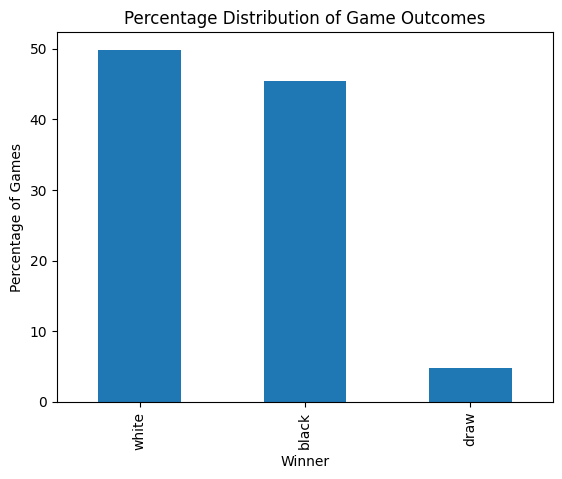

In [12]:
plt.figure()
winner_percent.plot(kind="bar")

plt.xlabel("Winner")
plt.ylabel("Percentage of Games")
plt.title("Percentage Distribution of Game Outcomes")

plt.show()

### Feature Engineering: Rating Difference

Create a new feature `rating_diff` = `white_rating` - `black_rating`, capturing the Elo rating gap between players.

**Impact:** This derived feature encodes the relative skill advantage of white over black, which is a strong predictor of game outcome.

In [13]:
df["rating_diff"] = df["white_rating"] - df["black_rating"]
df.head()

,rated,turns,winner,increment_code,white_rating,black_rating,opening_eco,opening_name,opening_ply,rating_diff
0,False,13,white,15+2,1500,1191,D10,Slav Defense: Exchange Variation,5,309
1,True,16,black,5+10,1322,1261,B00,Nimzowitsch Defense: Kennedy Variation,4,61
2,True,61,white,5+10,1496,1500,C20,King's Pawn Game: Leonardis Variation,3,-4
3,True,61,white,20+0,1439,1454,D02,Queen's Pawn Game: Zukertort Variation,3,-15
4,True,95,white,30+3,1523,1469,C41,Philidor Defense,5,54


### Inspect Unique Values of Categorical Columns

Examine the unique values in `winner`, `rated`, and `opening_name` to understand the cardinality and categories present.

**Impact:** Determines the encoding strategy — low-cardinality columns can be label-encoded while high-cardinality ones (like `opening_name`) may need to be dropped or grouped.

In [14]:
df["winner"].unique()

<StringArray>
['white', 'black', 'draw']
Length: 3, dtype: str

In [15]:
df["rated"].unique()

array([False,  True])

In [16]:
df["opening_name"].unique()

<StringArray>
[                                    'Slav Defense: Exchange Variation',
                               'Nimzowitsch Defense: Kennedy Variation',
                                'King's Pawn Game: Leonardis Variation',
                               'Queen's Pawn Game: Zukertort Variation',
                                                     'Philidor Defense',
                                 'Sicilian Defense: Mongoose Variation',
                           'Blackmar-Diemer Gambit: Pietrowsky Defense',
    'Nimzowitsch Defense: Kennedy Variation |  Linksspringer Variation',
                                'Italian Game: Schilling-Kostic Gambit',
                        'Scandinavian Defense: Mieses-Kotroc Variation',
 ...
               'Queen's Gambit Refused: Baltic Defense |  Queen Attack',
          'King's Indian Defense: Orthodox Variation |  Bayonet Attack',
              'King's Gambit |  Falkbeer Countergambit |  Miles Gambit',
                                

### Drop High-Cardinality Column: `opening_name`

The `opening_name` column has too many unique values to encode meaningfully. Drop it to simplify the model.

**Impact:** Prevents the curse of dimensionality — keeping hundreds of opening names would add noise without significant predictive power in a simple model.

In [17]:
df.drop(columns=["opening_name"], inplace=True)

### Verify Data After Dropping `opening_name`

Review the DataFrame structure after removing the high-cardinality column.

**Impact:** Confirms the column was dropped successfully and the remaining features are as expected.

In [18]:
df.head()

,rated,turns,winner,increment_code,white_rating,black_rating,opening_eco,opening_ply,rating_diff
0,False,13,white,15+2,1500,1191,D10,5,309
1,True,16,black,5+10,1322,1261,B00,4,61
2,True,61,white,5+10,1496,1500,C20,3,-4
3,True,61,white,20+0,1439,1454,D02,3,-15
4,True,95,white,30+3,1523,1469,C41,5,54


In [19]:
df.tail()

,rated,turns,winner,increment_code,white_rating,black_rating,opening_eco,opening_ply,rating_diff
20053,True,24,white,10+10,1691,1220,A80,2,471
20054,True,82,black,10+0,1233,1196,A41,2,37
20055,True,35,white,10+0,1219,1286,D00,3,-67
20056,True,109,white,10+0,1360,1227,B07,4,133
20057,True,78,black,10+0,1235,1339,D00,3,-104


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   rated           20058 non-null  bool 
 1   turns           20058 non-null  int64
 2   winner          20058 non-null  str  
 3   increment_code  20058 non-null  str  
 4   white_rating    20058 non-null  int64
 5   black_rating    20058 non-null  int64
 6   opening_eco     20058 non-null  str  
 7   opening_ply     20058 non-null  int64
 8   rating_diff     20058 non-null  int64
dtypes: bool(1), int64(5), str(3)
memory usage: 1.2 MB


### Inspect `increment_code` Column

Examine the unique values in `increment_code` to understand its format (e.g., `"10+0"`, `"15+10"`).

**Impact:** Understanding the format guides the feature engineering strategy — this column will be split into `base_time` and `increment` later.

In [21]:
df["increment_code"].unique()   

<StringArray>
[  '15+2',   '5+10',   '20+0',   '30+3',   '10+0',  '15+30',   '15+0',
  '20+60',   '5+40',    '8+0',
 ...
  '35+35',   '3+20',    '4+9',  '10+14',   '35+8',  '13+40',  '16+15',
 '60+180',   '8+45',  '14+15']
Length: 400, dtype: str

### Encode Target Variable: `winner`

Map the `winner` column from categorical strings to numerical values: `white → 1`, `black → 0`, `draw → 2`.

**Impact:** Converts the target variable into a machine-readable format required by classification algorithms.

In [22]:
df["winner"] = df["winner"].map({"white": 1, "black": 0, "draw": 2})

In [23]:
df['winner'].unique()

array([1, 0, 2])

### Re-map Winner Values

Swap the encoding so that `white win → 0` and `black win → 1` (draw remains `2`).

**Impact:** Adjusts the target encoding to the desired convention. This re-mapping changes which class is considered "positive" in binary classification.

In [24]:
df["winner"] = df["winner"].map({1: 0, 0: 1, 2: 2})

In [25]:
df["winner"].unique()

array([0, 1, 2])

### Encode `rated` Column

Convert the boolean `rated` column to integers: `True → 1`, `False → 0`.

**Impact:** Transforms the boolean feature into a numerical format suitable for ML models while preserving its binary nature.

In [26]:
df["rated"].unique()

array([False,  True])

In [27]:
df['rated'] = df['rated'].map({True: 1, False: 0})

In [28]:
df['rated'].unique()

array([0, 1])

### Verify Encoded Data

Review the current state of the DataFrame after all encoding operations.

**Impact:** Checkpoint to ensure all categorical-to-numeric conversions were applied correctly before further feature engineering.

In [29]:
df.head()

,rated,turns,winner,increment_code,white_rating,black_rating,opening_eco,opening_ply,rating_diff
0,0,13,0,15+2,1500,1191,D10,5,309
1,1,16,1,5+10,1322,1261,B00,4,61
2,1,61,0,5+10,1496,1500,C20,3,-4
3,1,61,0,20+0,1439,1454,D02,3,-15
4,1,95,0,30+3,1523,1469,C41,5,54


### Feature Engineering: Split `increment_code`

Split the `increment_code` column (format: `"base+increment"`) into two separate integer features: `base_time` and `increment`. Drop the original column.

**Impact:** Converts a single string column into two meaningful numerical features that capture time control settings — `base_time` (minutes) and `increment` (seconds per move).

In [30]:
df[["base_time", "increment"]] = df["increment_code"].str.split("+", expand=True)

df["base_time"] = df["base_time"].astype(int)
df["increment"] = df["increment"].astype(int)

df.drop(columns=["increment_code"], inplace=True)

In [31]:
df.head()

,rated,turns,winner,white_rating,black_rating,opening_eco,opening_ply,rating_diff,base_time,increment
0,0,13,0,1500,1191,D10,5,309,15,2
1,1,16,1,1322,1261,B00,4,61,5,10
2,1,61,0,1496,1500,C20,3,-4,5,10
3,1,61,0,1439,1454,D02,3,-15,20,0
4,1,95,0,1523,1469,C41,5,54,30,3


### Feature Engineering: Extract ECO Family

Extract the first letter of the `opening_eco` code (e.g., `"A"`, `"B"`, `"C"`) as a new feature `eco_family`, representing the opening family classification. Drop the original `opening_eco` column.

**Impact:** Reduces the cardinality of the ECO code from hundreds of unique values to just 5 families (A–E), making it manageable for encoding while retaining the strategic category of the opening.

In [32]:
df["eco_family"] = df["opening_eco"].str[0]
df.drop(columns=["opening_eco"], inplace=True)

In [33]:
df.head()

,rated,turns,winner,white_rating,black_rating,opening_ply,rating_diff,base_time,increment,eco_family
0,0,13,0,1500,1191,5,309,15,2,D
1,1,16,1,1322,1261,4,61,5,10,B
2,1,61,0,1496,1500,3,-4,5,10,C
3,1,61,0,1439,1454,3,-15,20,0,D
4,1,95,0,1523,1469,5,54,30,3,C


In [34]:
df["eco_family"].unique()

<StringArray>
['D', 'B', 'C', 'A', 'E']
Length: 5, dtype: str

### Encode `eco_family` to Numeric

Map the ECO family letters to integers: `A → 0`, `B → 1`, `C → 2`, `D → 3`, `E → 4`.

**Impact:** Completes the categorical encoding — all features are now numerical, making the dataset ready for ML algorithms.

In [35]:
df["eco_family"] = df["eco_family"].map({"A": 0, "B": 1, "C": 2, "D": 3, "E": 4})

In [36]:
df['eco_family'].unique()   

array([3, 1, 2, 0, 4])

In [37]:
df.head()

,rated,turns,winner,white_rating,black_rating,opening_ply,rating_diff,base_time,increment,eco_family
0,0,13,0,1500,1191,5,309,15,2,3
1,1,16,1,1322,1261,4,61,5,10,1
2,1,61,0,1496,1500,3,-4,5,10,2
3,1,61,0,1439,1454,3,-15,20,0,3
4,1,95,0,1523,1469,5,54,30,3,2


### Final Data Review After Encoding

Preview the fully encoded DataFrame from both head and tail to ensure consistency.

**Impact:** Final sanity check — all columns should now be numerical with no remaining string or categorical values.

In [38]:
df.tail()

,rated,turns,winner,white_rating,black_rating,opening_ply,rating_diff,base_time,increment,eco_family
20053,1,24,0,1691,1220,2,471,10,10,0
20054,1,82,1,1233,1196,2,37,10,0,0
20055,1,35,0,1219,1286,3,-67,10,0,3
20056,1,109,0,1360,1227,4,133,10,0,1
20057,1,78,1,1235,1339,3,-104,10,0,3


### Remove Draw Games

Filter out all games that ended in a draw (`winner == 2`) to convert the problem into **binary classification** (white win vs. black win). Reset the index afterward.

**Impact:** Simplifies the task from multiclass (3 classes) to binary classification, which improves model performance and interpretability when draws are a minority class.

In [39]:
df = df[df["winner"] != 2]

In [40]:
df.reset_index(drop=True, inplace=True)

### Verify Class Balance After Removing Draws

Check the percentage distribution of the remaining two classes (white win vs. black win).

**Impact:** Ensures the binary classes are reasonably balanced after removing draws, which affects model training and evaluation strategy.

In [41]:
df["winner"].value_counts(normalize=True) * 100

winner
0    52.339334
1    47.660666
Name: proportion, dtype: float64

In [42]:
df.head(10)

,rated,turns,winner,white_rating,black_rating,opening_ply,rating_diff,base_time,increment,eco_family
0,0,13,0,1500,1191,5,309,15,2,3
1,1,16,1,1322,1261,4,61,5,10,1
2,1,61,0,1496,1500,3,-4,5,10,2
3,1,61,0,1439,1454,3,-15,20,0,3
4,1,95,0,1523,1469,5,54,30,3,2
5,1,33,0,1520,1423,10,97,10,0,3
6,0,9,1,1413,2108,5,-695,15,30,1
7,1,66,1,1439,1392,6,47,15,0,2
8,1,119,0,1381,1209,4,172,10,0,1
9,0,39,0,1381,1272,1,109,20,60,0


---

## 4. Define Features and Target

### Separate Features (X) and Target (y)

Split the DataFrame into the **target variable** `y` (winner) and **feature matrix** `X` (all remaining columns).

**Impact:** Prepares the data for supervised learning — the model will learn patterns in `X` to predict `y`.

In [43]:
y = df["winner"]

In [44]:
X = df.drop(columns=["winner"])

### Verify Feature and Target Shapes

Print the dimensions of `X` and `y` along with the unique target values to confirm the setup.

**Impact:** Validates that the feature matrix and target vector are correctly shaped and the target contains the expected binary classes.

In [45]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("Target unique values:", y.unique())

Feature shape: (19108, 9)
Target shape: (19108,)
Target unique values: [0 1]


---

## 5. Model 1 — Logistic Regression (Full Feature Set)

### Train-Test Split

Split the data into 80% training and 20% testing sets using stratified sampling to preserve class proportions.

**Impact:** Ensures a fair and representative split — `stratify=y` guarantees both sets have the same class ratio, preventing bias in evaluation.

In [46]:
X.dtypes

rated           int64
turns           int64
white_rating    int64
black_rating    int64
opening_ply     int64
rating_diff     int64
base_time       int64
increment       int64
eco_family      int64
dtype: object

### Check Feature Data Types

Verify that all features are numerical — a prerequisite for most ML algorithms.

**Impact:** Confirms readiness for modeling. Any remaining non-numeric types would need additional encoding.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

### Feature Scaling (StandardScaler)

Standardize features by removing the mean and scaling to unit variance. Fit the scaler on training data only, then transform both train and test sets.

**Impact:** Logistic Regression is sensitive to feature scales. Standardization ensures all features contribute equally and improves convergence speed. Fitting only on training data prevents **data leakage**.

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Logistic Regression Model

Instantiate and train a Logistic Regression classifier with `max_iter=1000` on the scaled training data.

**Impact:** Logistic Regression serves as a **baseline model** — it is interpretable, fast to train, and provides coefficient-based feature importance. The increased `max_iter` ensures convergence on this dataset.

In [49]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Evaluate Model Performance

Generate predictions on the test set and compute accuracy, precision, recall, and F1-score using the classification report.

**Impact:** Provides a comprehensive view of model performance across both classes, going beyond simple accuracy to reveal per-class strengths and weaknesses.

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6465201465201466

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.71      0.68      2000
           1       0.64      0.58      0.61      1822

    accuracy                           0.65      3822
   macro avg       0.65      0.64      0.64      3822
weighted avg       0.65      0.65      0.64      3822



### Confusion Matrix Visualization

Plot a heatmap of the confusion matrix to visualize true positives, true negatives, false positives, and false negatives.

**Impact:** Provides an intuitive visual assessment of where the model makes correct vs. incorrect predictions, highlighting any systematic misclassification patterns.

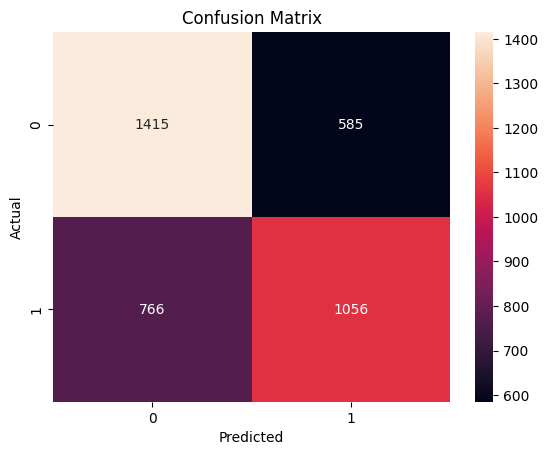

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Feature Importance Analysis

Extract the absolute values of the Logistic Regression coefficients to determine which features have the strongest influence on predictions.

**Impact:** Identifies the most important predictors — features with larger absolute coefficients have a greater influence on the model's decision boundary.

In [52]:
feature_importances = pd.Series(
    np.abs(model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

print(feature_importances * 100)

rating_diff     70.862798
black_rating    32.354676
white_rating    29.351117
turns            6.904519
opening_ply      4.010141
increment        1.462548
rated            0.479236
base_time        0.442833
eco_family       0.230898
dtype: float64


### Feature Importance Bar Chart

Visualize the relative importance of each feature as a bar chart.

**Impact:** Makes it easy to compare feature contributions visually. This chart guides feature selection — features with very low importance may be candidates for removal.

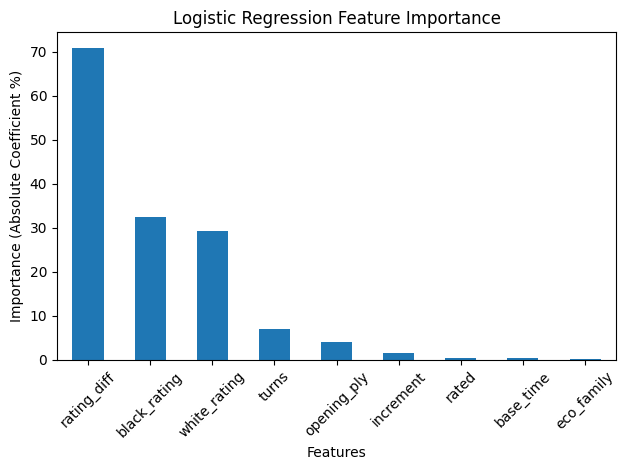

In [53]:
importance = feature_importances * 100

plt.figure()
importance.plot(kind="bar")

plt.xlabel("Features")
plt.ylabel("Importance (Absolute Coefficient %)")
plt.title("Logistic Regression Feature Importance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

---

## 6. Model 2 — Logistic Regression (Reduced Feature Set)

### Drop Redundant Features

Remove `white_rating` and `black_rating` since the derived feature `rating_diff` already captures their relationship. This tests whether a simpler model performs comparably.

**Impact:** Reduces multicollinearity and simplifies the model. If performance holds, it confirms that the rating difference is more informative than the individual ratings.

In [54]:
X = X.drop(columns=["white_rating", "black_rating"])

In [55]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("Target unique values:", y.unique())

Feature shape: (19108, 7)
Target shape: (19108,)
Target unique values: [0 1]


### Re-split and Re-scale Data

Perform a new train-test split and feature scaling on the reduced feature set.

**Impact:** Ensures a clean pipeline — the reduced feature set gets its own properly fitted scaler and split, avoiding contamination from the previous iteration.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train and Evaluate Reduced Logistic Regression

Train a new Logistic Regression model on the reduced (7 features) scaled data and evaluate its performance.

**Impact:** Allows direct comparison with the full-feature model — if accuracy is similar, the reduced model is preferred due to simplicity (Occam's razor).

In [58]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6478283621140764

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.71      0.68      2000
           1       0.65      0.58      0.61      1822

    accuracy                           0.65      3822
   macro avg       0.65      0.64      0.64      3822
weighted avg       0.65      0.65      0.65      3822



---

## 7. Model 3 — Random Forest Classifier

### Train Random Forest

Train a Random Forest classifier with 300 trees on the reduced feature set (unscaled — tree-based models are scale-invariant).

**Impact:** Random Forest is an ensemble method that captures non-linear relationships and feature interactions. It provides a strong benchmark against the linear Logistic Regression model.

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,    
    max_depth=None,       
    random_state=42,
    n_jobs=-1            
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [61]:
y_pred_rf = rf.predict(X_test)

### Evaluate Random Forest

Generate predictions and compute accuracy, precision, recall, and F1-score for the Random Forest model.

**Impact:** Enables a direct performance comparison between Logistic Regression and Random Forest, determining whether non-linear modeling adds value for this dataset.

In [62]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6985871271585558

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.72      0.72      2000
           1       0.69      0.67      0.68      1822

    accuracy                           0.70      3822
   macro avg       0.70      0.70      0.70      3822
weighted avg       0.70      0.70      0.70      3822



### Random Forest Confusion Matrix

Visualize the confusion matrix for the Random Forest model.

**Impact:** Compares the error patterns of Random Forest with Logistic Regression — helps identify if the ensemble model reduces specific types of misclassification.

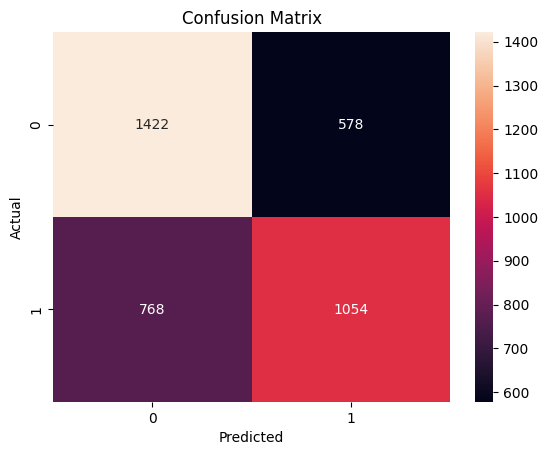

In [63]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Random Forest Feature Importance

Extract and visualize the feature importances from the Random Forest model (based on Gini impurity reduction).

**Impact:** Tree-based feature importance offers a different perspective than logistic regression coefficients — it reflects how much each feature contributes to reducing classification error across all trees.

rating_diff    39.387734
turns          29.155314
opening_ply     9.439275
base_time       8.273973
increment       6.939518
eco_family      4.994318
rated           1.809868
dtype: float64


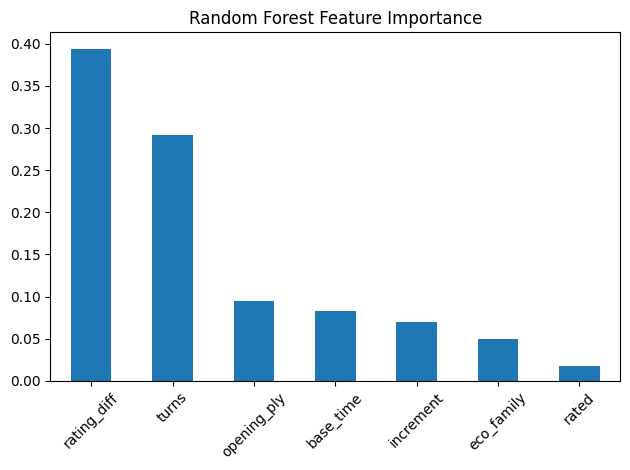

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(rf_importance * 100)

plt.figure()
rf_importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## 8. Model Comparison — 5-Fold Cross-Validation

### Cross-Validation Across All Models

Perform 5-fold cross-validation on three model configurations:
1. **LR (Full 9 features)** — Logistic Regression with all features including individual ratings
2. **LR (Reduced 7 features)** — Logistic Regression without `white_rating` and `black_rating`
3. **Random Forest (7 features)** — Ensemble model on the reduced feature set

**Impact:** Cross-validation provides a robust and unbiased estimate of model generalization by testing on 5 different folds. This eliminates the risk of a lucky/unlucky single split and enables reliable model comparison.

In [65]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline


X_full = df.drop(columns=["winner"])


X_reduced = X.copy()


lr_full_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
lr_full_scores = cross_val_score(lr_full_pipeline, X_full, y, cv=5)

lr_reduced_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
lr_reduced_scores = cross_val_score(lr_reduced_pipeline, X_reduced, y, cv=5)

rf_cv = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf_cv, X_reduced, y, cv=5)

print("5-Fold Cross-Validation Results:")
print(f"  LR (Full 9 features):    {lr_full_scores.mean():.4f} ± {lr_full_scores.std():.4f}")
print(f"  LR (Reduced 7 features): {lr_reduced_scores.mean():.4f} ± {lr_reduced_scores.std():.4f}")
print(f"  Random Forest (7 feat):  {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

5-Fold Cross-Validation Results:
  LR (Full 9 features):    0.6542 ± 0.0067
  LR (Reduced 7 features): 0.6549 ± 0.0059
  Random Forest (7 feat):  0.6915 ± 0.0113


### Visualize Cross-Validation Results

Create a bar chart comparing the mean CV accuracy (with standard deviation error bars) across all three model configurations.

**Impact:** Provides a clear, publication-ready visual summary of model performance, making it straightforward to identify the best-performing approach and assess the stability of each model's predictions.

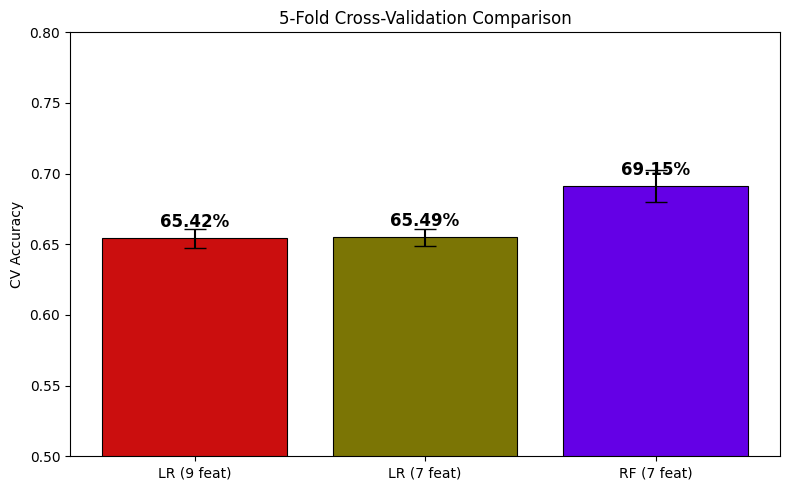

In [66]:
models = ["LR (9 feat)", "LR (7 feat)", "RF (7 feat)"]
means = [lr_full_scores.mean(), lr_reduced_scores.mean(), rf_scores.mean()]
stds = [lr_full_scores.std(), lr_reduced_scores.std(), rf_scores.std()]
colors = ["#CB0E0E", "#7B7505", "#6400E6"]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, means, yerr=stds, capsize=8, color=colors, edgecolor="black", linewidth=0.8)

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{mean:.2%}", ha="center", va="bottom", fontweight="bold", fontsize=12)

plt.ylabel("CV Accuracy")
plt.title("5-Fold Cross-Validation Comparison")
plt.ylim(0.5, 0.8)
plt.tight_layout()
plt.show()